Code to generate Figure 5subplots

In [7]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../flatten/processed-data/"
DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [8]:
# load the datasets with node centrality information and get nodes in both
#ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")

# --- Flip sign of cagiada-dG so downstream code uses the corrected values ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(nodes.columns)

In [9]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [10]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

#y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
#y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
#y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01503; there are 252 hubs and 2214 non hubs


In [11]:
# Step 2.1: Load chaperone data
# Parse the interacting_chaperones column if it's a string representation of a list
nodes['interacting_chaperones'] = nodes['interacting_chaperones'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Compute number of chaperone interactions
nodes['num_chaperone_interactions'] = nodes['interacting_chaperones'].apply(len)

# Step 2.2: Compute total degree from full MS interactome
f_ms_edges = pd.read_csv(f"{DATA_PATH1}The_Yeast_Interactome_edges.csv")
f_ms_edges = f_ms_edges.rename(columns={"source": "node1", "target": "node2"})

G = nx.from_pandas_edgelist(f_ms_edges, "node1", "node2", create_using=nx.Graph())
degree_dict = dict(G.degree())

degree_df = pd.DataFrame({
    "node": list(degree_dict.keys()),
    "total_degree": list(degree_dict.values())
})

# Step 2.3: Merge degree and compute chaperone fraction
#Now every protein has: number of chaperone contacts, total degree, fraction of interactions involving chaperones
merged_df = nodes.merge(degree_df, left_on="node", right_on="node", how="inner")
merged_df = merged_df[merged_df['total_degree'] > 0] # avoid divide-by-zero
merged_df['chaperone_fraction'] = (merged_df['num_chaperone_interactions'] / merged_df['total_degree'])

# Step 2.4: Integrate classifications
class_df = filtered_nodes[['node', 'in_complex']].copy()

# Hub assignment
class_df['is_hub'] = class_df['node'].isin(ms_hubs['node'])

# Define hub type:
# static  = hub & in_complex == True
# dynamic = hub & in_complex == False
# nonhub  = everything else
def assign_hub_type(row):
    if row['is_hub']:
        return "static" if row['in_complex'] else "dynamic"
    else:
        return "nonhub"

class_df['hub_type'] = class_df.apply(assign_hub_type, axis=1)

# Merge classification into merged_df
final_df = merged_df.merge(
    class_df[['node', 'is_hub', 'hub_type']],
    on='node',
    how='left'
)

# Define simple chaperone boolean
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

#print(final_df.head())

In [12]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()
    
# Extract chaperone fraction for hubs vs non-hubs
hub_frac = final_df[final_df["is_hub"] == True]["chaperone_fraction"]\
                .replace([np.inf, -np.inf], np.nan).dropna()

nonhub_frac = final_df[final_df["is_hub"] == False]["chaperone_fraction"]\
                .replace([np.inf, -np.inf], np.nan).dropna()

print(f"Hub count: {len(hub_frac)}")
print(f"Non-hub count: {len(nonhub_frac)}")

# Groups: (label, data, color)
groups = [
    ("Hubs",     hub_frac,    MS_COLOR),
    ("Non-hubs", nonhub_frac, MS_COLOR),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Hub count: 252
Non-hub count: 2214


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 76366.83it/s]


Hubs: median=0.00, 95% CI=(0.00, 0.00), n=252)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:25<00:00, 38584.60it/s]

Non-hubs: median=0.00, 95% CI=(0.00, 0.00), n=2214)


In [13]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_frac, nonhub_frac, alternative="two-sided")

print("=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===")

print("\nHub + Chaperone vs Hub + NoChaperone")
print(f"n(hubs) = {len(hub_frac)}, n(nonhubs) = {len(nonhub_frac)}")
print(f"median(hubs) = {np.median(hub_frac):.2f}, median(nonhubs) = {np.median(nonhub_frac):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

#How many hubs have ≥1 chaperone contact?
print("Hubs:", 
      (final_df[final_df["is_hub"] == True]["num_chaperone_interactions"] > 0).mean())
#How many nonhubs have ≥1 chaperone contact?
print("Nonhubs:", 
      (final_df[final_df["is_hub"] == False]["num_chaperone_interactions"] > 0).mean())

=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===

Hub + Chaperone vs Hub + NoChaperone
n(hubs) = 252, n(nonhubs) = 2214
median(hubs) = 0.00, median(nonhubs) = 0.00
U = 317619.50, p = 2.212e-08
Hubs: 0.3253968253968254
Nonhubs: 0.14588979223125564


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_30675/3573623827.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


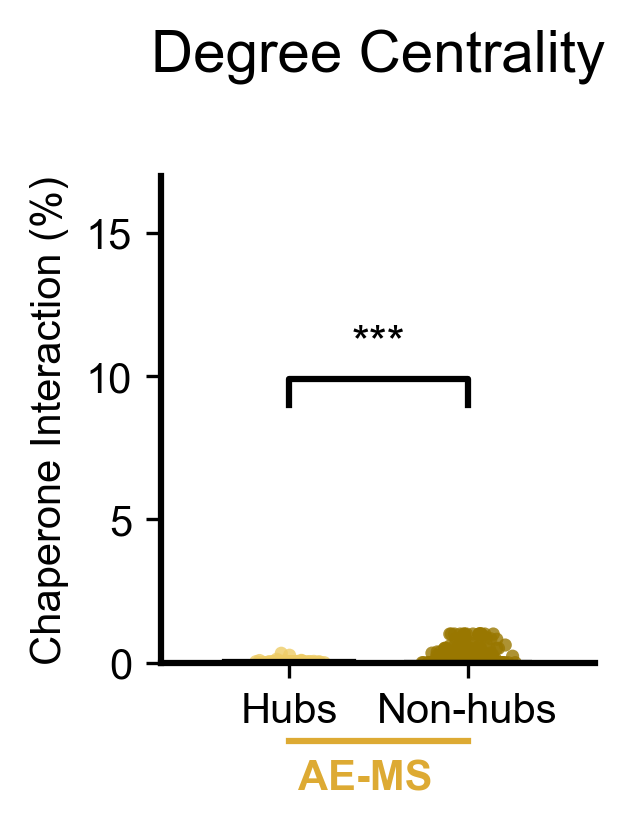

In [32]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals = [hub_frac, nonhub_frac]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Hubs", "Non-hubs"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)
        
# --- Axes styling ---
ax.set_ylabel("Chaperone Interaction (%)")
ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(hub_frac.min(), nonhub_frac.min())
y_max = max(hub_frac.max(), nonhub_frac.max())

# Significance bracket slightly above the highest data point
bracket_y = y_max + 8

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 8)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.3, -0.20, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6.svg")
plt.show()

/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_30675/302935056.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


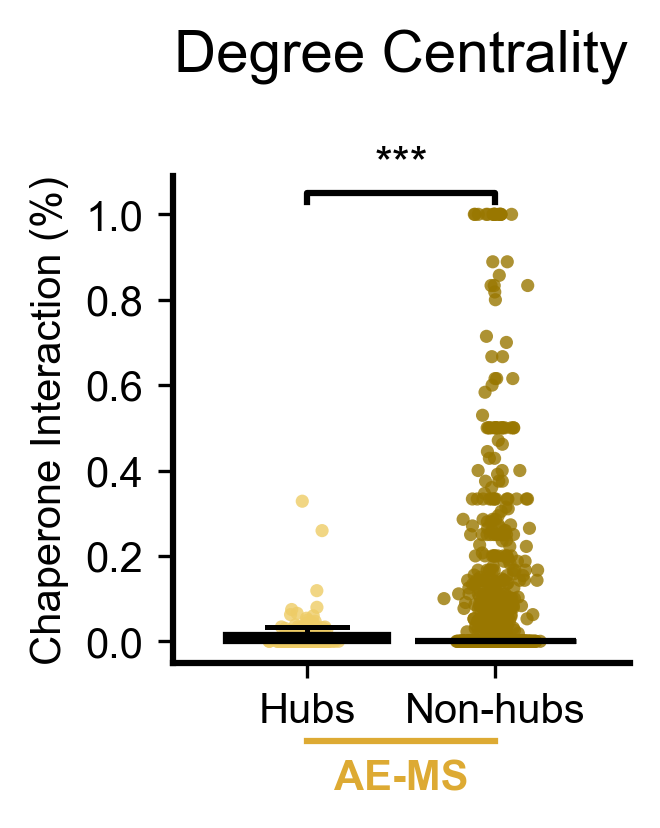

In [88]:
# -------------------------
# Function for bracket text
# -------------------------
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 0.02     # tiny bump above the bracket line
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 0.015,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )


# -------------------------
# Begin plotting
# -------------------------
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [hub_frac, nonhub_frac]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]
positions    = [1, 1.7]

# --- Scatter ---
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots ---
bp = ax.boxplot(
    group_vals,
    labels=["Hubs", "Non-hubs"],
    positions=positions,
    widths=0.6,               # slightly wider to improve visibility
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)


# ----------------------------
# Y–AXIS FIX (your request #1)
# ----------------------------
#ax.set_ylim(-0.1, max(hub_frac.max(), nonhub_frac.max()) + 0.15)
y_low = -0.05                  
y_high = 1.09
#y_high = max(hub_frac.max(), nonhub_frac.max()) + 0.04

ax.set_ylim(y_low, y_high)


# ----------------------------
# Custom y-axis ticks (your request)
# ----------------------------
yticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=10)


# ----------------------------
# SIGNIFICANCE BAR (Manual) 
# (your request #2)
# ----------------------------

# Choose exactly where YOU want the bracket
bracket_y = max(hub_frac.max(), nonhub_frac.max()) + 0.03   # adjust manually anytime

add_bracket_with_text(
    ax,
    positions[0],      # x-start (1)
    positions[1],      # x-end   (1.7)
    bracket_y,
    "***"              # significance text
)


# -------------------------
# Same bottom label (boss style)
# -------------------------
trans = ax.get_xaxis_transform()

ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.20, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)


# -------------------------
# Axes cosmetics
# -------------------------
ax.set_ylabel("Chaperone Interaction (%)")
ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6-a.svg")
plt.show()


In [85]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

# Extract chaperone fraction for Static vs Dynamic Hubs
# Extract static and dynamic hubs
static_df  = final_df[final_df["hub_type"] == "static"].copy()
dynamic_df = final_df[final_df["hub_type"] == "dynamic"].copy()

# Clean values
static_frac = static_df["chaperone_fraction"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_frac = dynamic_df["chaperone_fraction"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

print(f"Static hubs count:  {len(static_frac)}")
print(f"Dynamic hubs count: {len(dynamic_frac)}")

# Groups: (label, data, color)
groups = [
    ("Hubs",     static_frac,    MS_COLOR),
    ("Non-hubs", dynamic_frac, MS_COLOR),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Static hubs count:  134
Dynamic hubs count: 118


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 83054.33it/s]


Hubs: median=0.00, 95% CI=(0.00, 0.00), n=134)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 81260.78it/s]

Non-hubs: median=0.00, 95% CI=(0.00, 0.01), n=118)


In [86]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(static_frac, dynamic_frac, alternative="two-sided")

print("=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===")

print("\nHub + Chaperone vs Hub + NoChaperone")
print(f"n(static)  = {len(static_frac)}, n(dynamic) = {len(dynamic_frac)}")
print(f"median(static) = {np.median(static_frac):.2f}, median(dynamic) = {np.median(dynamic_frac):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# Mean boolean (≥1 chaperone contact)
print("Static hubs (bool):", 
      (final_df[final_df["hub_type"] == "static"]["num_chaperone_interactions"] > 0).mean())

print("Dynamic hubs (bool):", 
      (final_df[final_df["hub_type"] == "dynamic"]["num_chaperone_interactions"] > 0).mean())

=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===

Hub + Chaperone vs Hub + NoChaperone
n(static)  = 134, n(dynamic) = 118
median(static) = 0.00, median(dynamic) = 0.00
U = 5852.00, p = 1.934e-05
Static hubs (bool): 0.19402985074626866
Dynamic hubs (bool): 0.4745762711864407


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_30675/2137775128.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


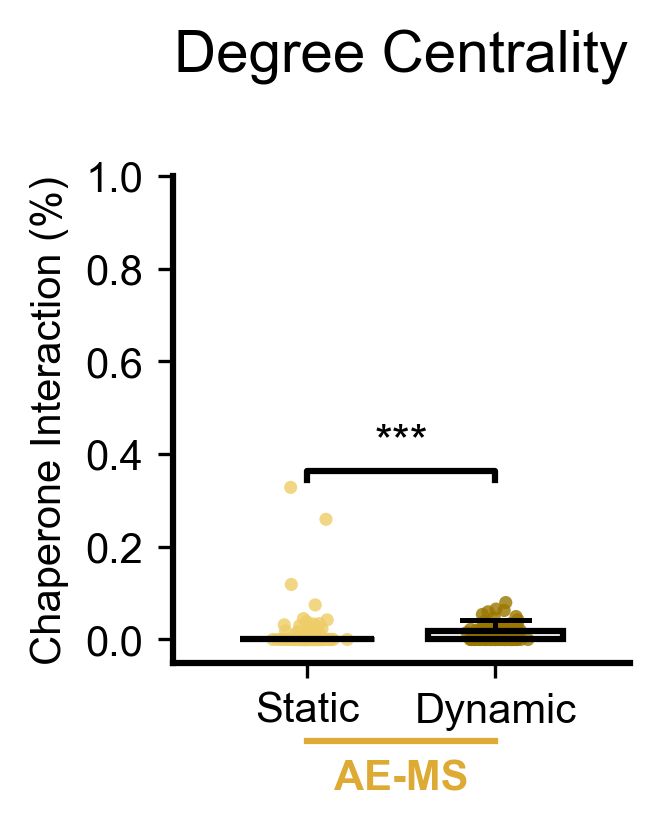

In [90]:
# -------------------------
# Function for bracket text
# -------------------------
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 0.02     # tiny bump above the bracket line
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 0.015,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )


# -------------------------
# Begin plotting
# -------------------------
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [static_frac, dynamic_frac]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]
positions    = [1, 1.7]


# -------------------------
# Scatter points
# -------------------------
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )


# -------------------------
# Boxplots
# -------------------------
bp = ax.boxplot(
    group_vals,
    labels=["Static", "Dynamic"],
    positions=positions,
    widths=0.5,                 # keep original advisor style
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)


# -------------------------
# Y-axis tuning (same logic as first plot)
# -------------------------
y_low  = -0.05
y_high = 0.5
#y_high = max(static_frac.max(), dynamic_frac.max()) + 0.03

ax.set_ylim(y_low, y_high)


# -------------------------
# Custom Y-ticks (same as first plot)
# -------------------------
yticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=10)


# -------------------------
# Significance bracket
# -------------------------
bracket_y = max(static_frac.max(), dynamic_frac.max()) + 0.015

add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")


# -------------------------
# AE-MS underline (unchanged)
# -------------------------
trans = ax.get_xaxis_transform()

ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.20, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)


# -------------------------
# Axis cosmetics
# -------------------------
ax.set_ylabel("Chaperone Interaction (%)")
ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}7.svg")
plt.show()


/tmp/ipykernel_39003/2474886293.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


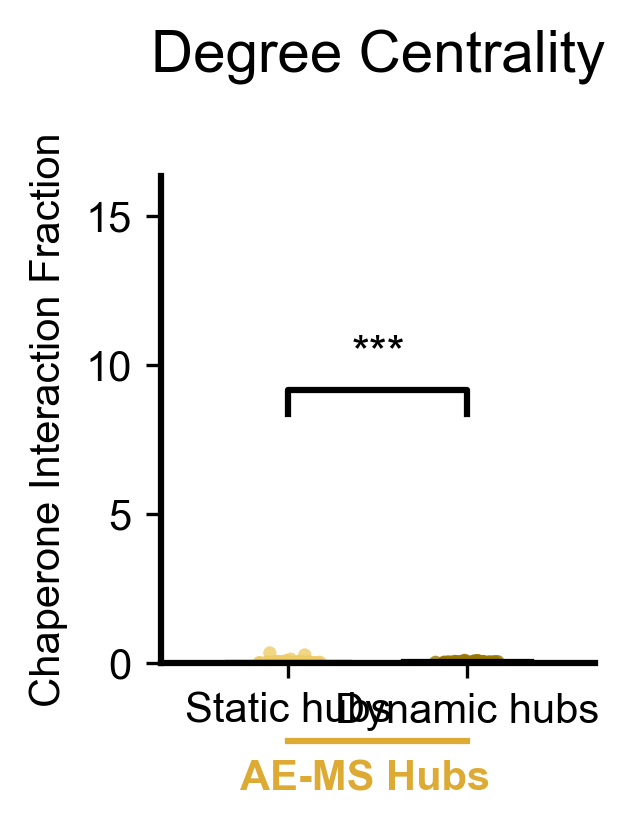

In [20]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [static_frac, dynamic_frac]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Static", "Dynamic"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Chaperone Interaction Fraction")
ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(static_frac.min(), dynamic_frac.min())
y_max = max(static_frac.max(), dynamic_frac.max())

# Significance bracket slightly above the highest data point
bracket_y = y_max + 8

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 8)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.3, -0.20, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6.svg")
plt.show()

In [40]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import hypergeom

# --- Parse GO terms from columns ---
# Split semicolon-separated GO IDs
# Just to be safe: replace NaNs with empty strings
final_df["GO_terms"] = final_df["GO_terms"].fillna("")
final_df["GO_terms_human_readable"] = final_df["GO_terms_human_readable"].fillna("")

# Parse GO IDs into a Python list per protein ---
# Example: "GO:0005737;GO:0005937" → ["GO:0005737", "GO:0005937"]
final_df["GO_list"] = final_df["GO_terms"].apply(
    lambda s: [g.strip() for g in s.split(";") if g.strip() != ""]
)

# Parse human-readable mapping GO_ID -> name ---
# Handles formats like:
# "GO:0005737: cytoplasm;GO:0005886: plasma membrane"
def parse_readable_row(s):
    items = [x.strip() for x in s.split(";") if x.strip() != ""]
    mapping = {}
    for it in items:
        if not it.startswith("GO:"):
            continue
        # split only on the first two ":", so we can reconstruct GO:0005737
        parts = it.split(":", 2)  # e.g. ["GO","0005737"," cytoplasm"]
        if len(parts) >= 3:
            go_id = parts[0] + ":" + parts[1]   # "GO:0005737"
            name = parts[2].strip()
            mapping[go_id] = name
        elif len(parts) == 2:
            # case like "GO:0004127" with no name
            go_id = parts[0] + ":" + parts[1]
            mapping.setdefault(go_id, go_id)
    return mapping

final_df["GO_readable_dict"] = final_df["GO_terms_human_readable"].apply(parse_readable_row)

# Global map GO_ID -> name (so we can look up names later)
go_name_map = {}
for d in final_df["GO_readable_dict"]:
    go_name_map.update(d)

print("Example GO mapping (first 10):")
print(list(go_name_map.items())[:10])

Example GO mapping (first 10):
[('GO:0005794', 'Golgi apparatus'), ('GO:0005737', 'cytoplasm'), ('GO:0005937', 'mating projection'), ('GO:0005886', 'plasma membrane'), ('GO:0000753', 'cell morphogenesis involved in conjugation with cellular fusion'), ('GO:0008360', 'regulation of cell shape'), ('GO:0071944', 'cell periphery'), ('GO:0005739', 'mitochondrion'), ('GO:0005524', 'ATP binding'), ('GO:0016887', 'ATP hydrolysis activity')]


In [42]:
# Dynamic hubs with chaperone interactions
dynamic_chap = final_df[
    (final_df["hub_type"] == "dynamic") &
    (final_df["num_chaperone_interactions"] > 0)
].copy()

background = final_df.copy()

print("Dynamic+Chaperone n =", len(dynamic_chap))
all_terms = [t for lst in dynamic_chap["GO_list"] for t in lst]
print("Unique GO terms in Dynamic+Chaperone =", len(set(all_terms)))

go_enrich.sort_values("p_value").head(20)

Dynamic+Chaperone n = 56
Unique GO terms in Dynamic+Chaperone = 132


,GO_ID,GO_name,k_test,K_background,fold_enrichment,p_value,FDR
3,GO:0022625,None,37,82,31.641768,1.687351e-52,2.227304e-50
1,GO:0002181,None,41,132,21.781250,5.153494e-51,3.401306e-49
2,GO:0003735,None,40,215,13.046512,1.764241e-39,7.762661e-38
0,GO:0005829,None,46,821,3.929050,7.878522e-23,2.599912e-21
4,GO:0003723,None,26,260,7.012500,7.307288e-17,1.929124e-15
13,GO:0000470,None,6,20,21.037500,2.126443e-07,4.678174e-06
9,GO:0000027,None,7,39,12.586538,8.824563e-07,1.664060e-05
7,GO:0030687,None,8,61,9.196721,1.679163e-06,2.770618e-05
26,GO:0042255,None,3,4,52.593750,1.088258e-05,1.596111e-04
12,GO:0042273,None,6,61,6.897541,1.941781e-04,2.563151e-03


In [43]:
# --- 3A. Background GO counts ---
all_go_bg = []
for lst in background["GO_list"]:
    all_go_bg.extend(lst)
background_counts = pd.Series(all_go_bg).value_counts()

# --- 3B. Test GO counts (dynamic + chaperone) ---
all_go_test = []
for lst in dynamic_chap["GO_list"]:
    all_go_test.extend(lst)
test_counts = pd.Series(all_go_test).value_counts()

# We'll only test GO terms that appear at least 2 times in the test set
unique_go_terms = test_counts[test_counts >= 2].index

results = []
N = len(background)        # universe size
n = len(dynamic_chap)      # test set size

for go in unique_go_terms:
    K = background_counts.get(go, 0)   # count in background
    k = test_counts.get(go, 0)         # count in test set
    if K == 0:
        continue

    # hypergeometric P(X >= k)
    pval = hypergeom.sf(k - 1, N, K, n)
    fold = (k / n) / (K / N)

    # human-readable name from global map, fallback to GO ID
    readable = go_name_map.get(go, go)

    results.append([go, readable, k, K, fold, pval])

go_enrich = pd.DataFrame(
    results,
    columns=["GO_ID", "GO_name", "k_test", "K_background", "fold_enrichment", "p_value"]
)

print("Total GO terms tested:", len(go_enrich))

if len(go_enrich) == 0:
    print("No GO terms met the minimum criteria (freq >= 2 in test set).")
else:
    # FDR correction
    go_enrich["FDR"] = multipletests(go_enrich["p_value"], method="fdr_bh")[1]
    # sort by FDR and keep top 15
    go_sig = go_enrich.sort_values("FDR").head(15)
    print(go_sig)


Total GO terms tested: 49
         GO_ID                                            GO_name  k_test  \
3   GO:0022625                  cytosolic large ribosomal subunit      37   
1   GO:0002181                            cytoplasmic translation      41   
2   GO:0003735                 structural constituent of ribosome      40   
0   GO:0005829                                            cytosol      46   
4   GO:0003723                                        RNA binding      26   
13  GO:0000470                             maturation of LSU-rRNA       6   
9   GO:0000027                   ribosomal large subunit assembly       7   
7   GO:0030687               preribosome, large subunit precursor       8   
26  GO:0042255                                  ribosome assembly       3   
12  GO:0042273                 ribosomal large subunit biogenesis       6   
25  GO:0000448  cleavage in ITS2 between 5.8S rRNA and LSU-rRN...       3   
15  GO:0019843                                    

/tmp/ipykernel_39003/3780697764.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


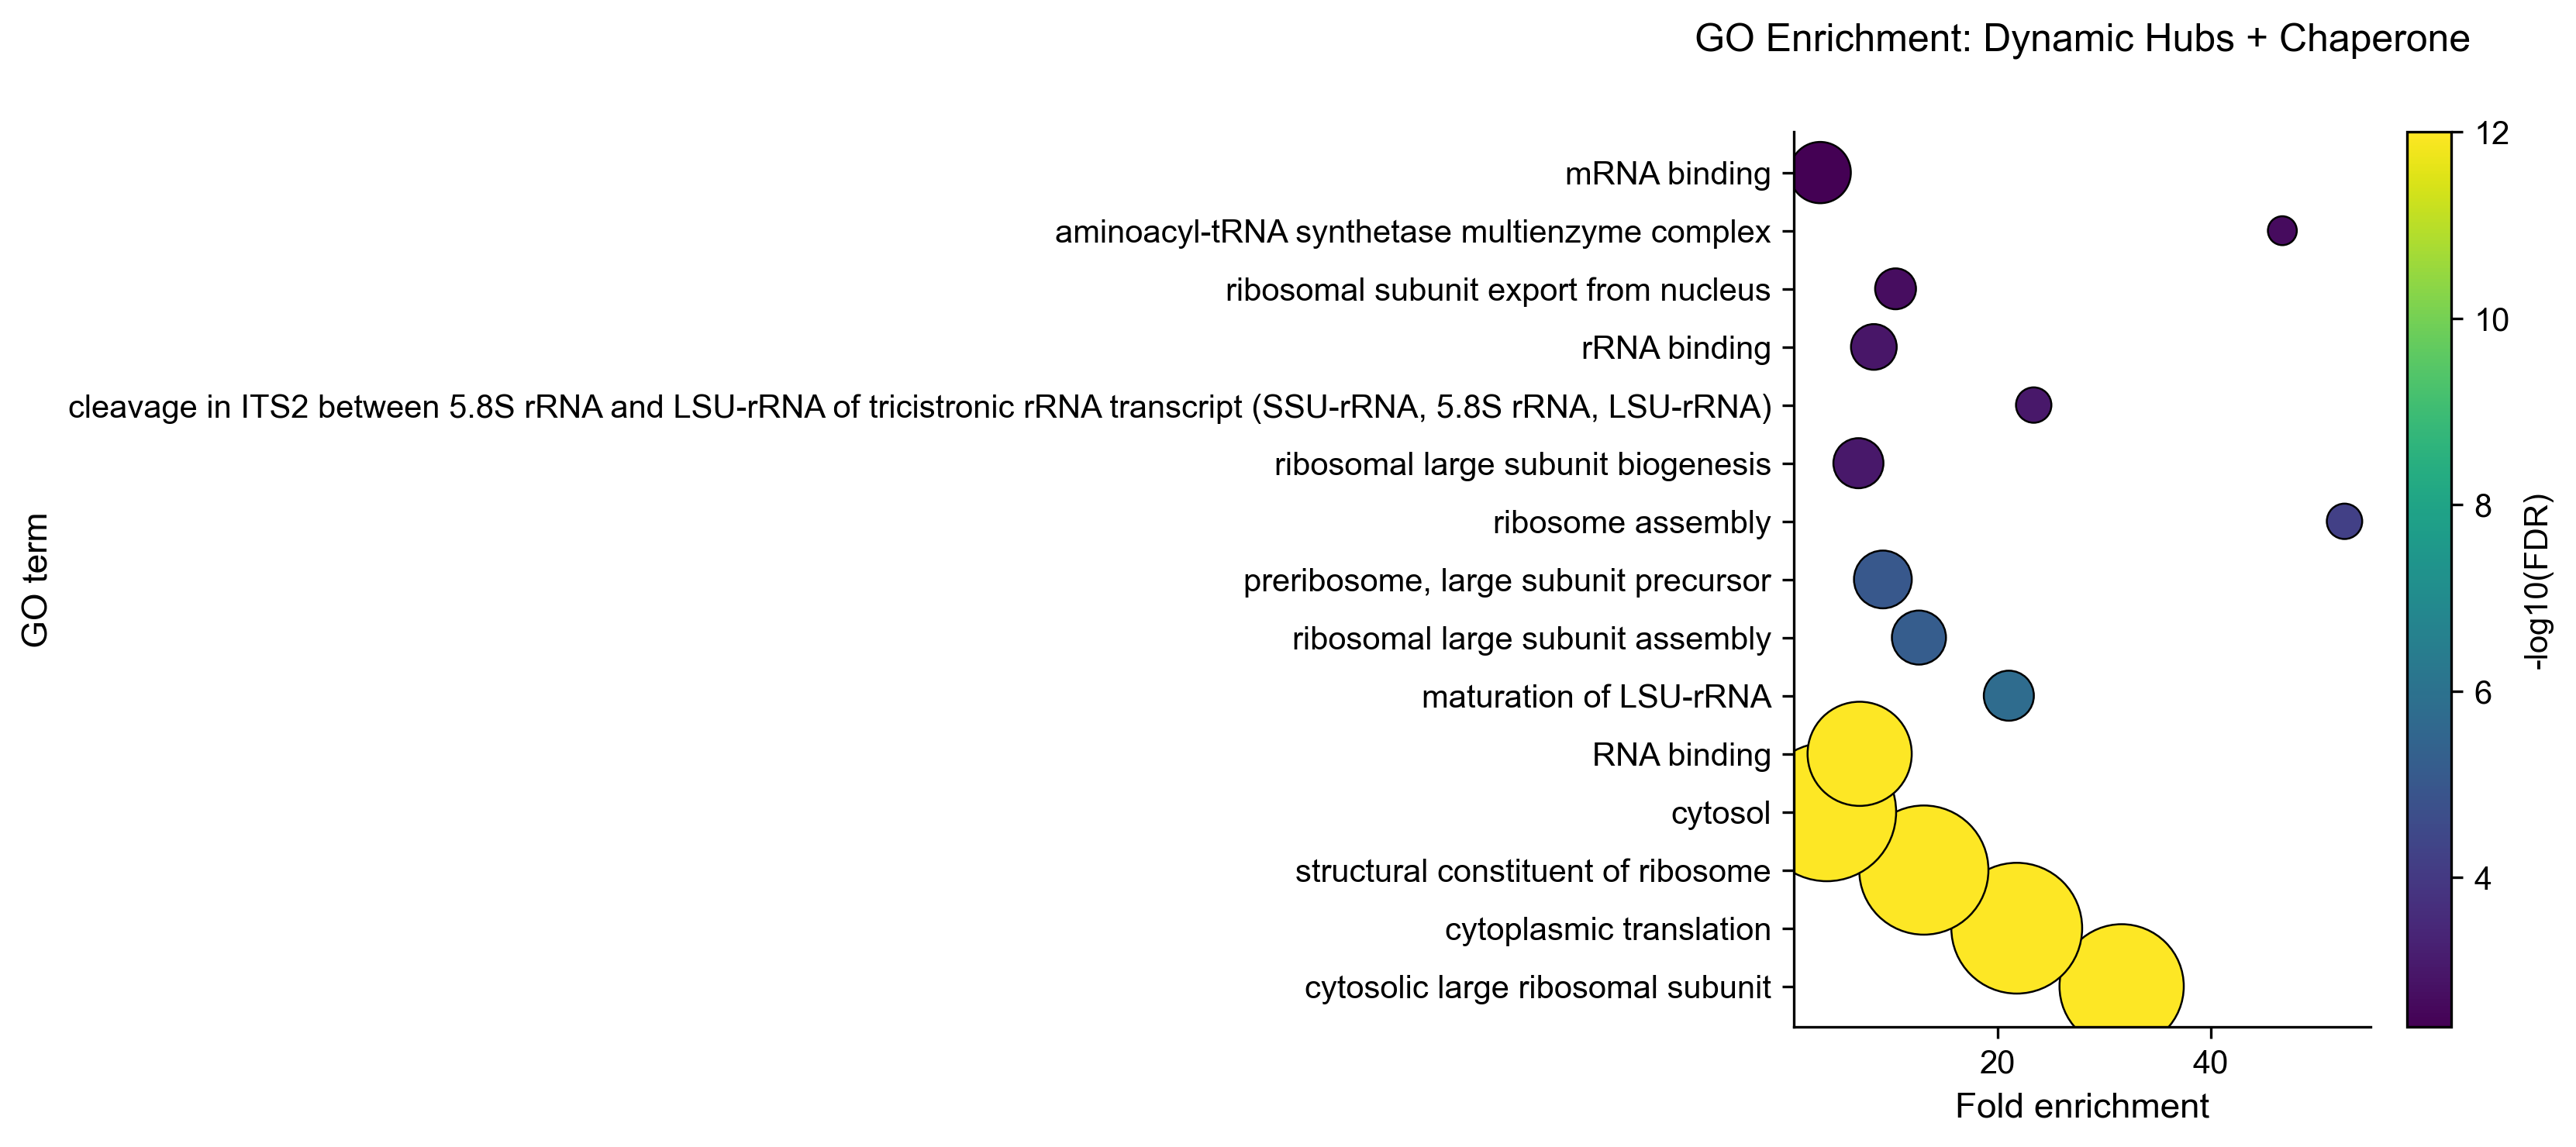

In [44]:
if len(go_enrich) > 0:

    plot_df = go_enrich.sort_values("FDR").head(15).copy()
    plot_df["neglog10FDR"] = -np.log10(plot_df["FDR"] + 1e-12)

    # Use human-readable name when available, otherwise GO ID
    plot_df["label"] = plot_df.apply(
        lambda r: r["GO_name"] if pd.notna(r["GO_name"]) and r["GO_name"] != "" else r["GO_ID"],
        axis=1
    )

    fig, ax = plt.subplots(figsize=(4, 5))

    scatter = ax.scatter(
        plot_df["fold_enrichment"],
        plot_df["label"],
        s=plot_df["k_test"] * 40,
        c=plot_df["neglog10FDR"],
        cmap="viridis",
        edgecolors="black",
        linewidth=0.6,
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("-log10(FDR)", fontsize=10)

    ax.set_xlabel("Fold enrichment", fontsize=11)
    ax.set_ylabel("GO term", fontsize=11)
    ax.set_title("GO Enrichment: Dynamic Hubs + Chaperone", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUT_PATH}GO_dynamic_chap_dotplot.svg", dpi=300)
    plt.show()


In [45]:
# Static hubs with ≥1 chaperone interaction
static_chap = final_df[
    (final_df["hub_type"] == "static") &
    (final_df["num_chaperone_interactions"] > 0)
].copy()

background = final_df.copy()

print("Static + Chaperone n =", len(static_chap))


Static + Chaperone n = 26


In [46]:
# --- Background GO counts ---
all_go_bg = []
for lst in background["GO_list"]:
    all_go_bg.extend(lst)
background_counts = pd.Series(all_go_bg).value_counts()

# --- Test GO counts ---
all_go_test = []
for lst in static_chap["GO_list"]:
    all_go_test.extend(lst)
test_counts = pd.Series(all_go_test).value_counts()

# Only GO terms appearing ≥2 times in test set
unique_go_terms = test_counts[test_counts >= 2].index

results = []
N = len(background)
n = len(static_chap)

for go in unique_go_terms:
    K = background_counts.get(go, 0)
    k = test_counts.get(go, 0)

    if K == 0:
        continue

    pval = hypergeom.sf(k - 1, N, K, n)
    fold = (k/n) / (K/N)

    # readable name from go_name_map
    readable = go_name_map.get(go, go)

    results.append([go, readable, k, K, fold, pval])

static_go = pd.DataFrame(
    results,
    columns=["GO_ID", "GO_name", "k_test", "K_background", "fold_enrichment", "p_value"]
)

if len(static_go) == 0:
    print("No GO terms met criteria.")
else:
    static_go["FDR"] = multipletests(static_go["p_value"], method="fdr_bh")[1]
    static_go_sig = static_go.sort_values("FDR").head(15)
    print(static_go_sig)


         GO_ID                                GO_name  k_test  K_background  \
3   GO:0002181                cytoplasmic translation      12           132   
4   GO:0003735     structural constituent of ribosome      10           215   
5   GO:0022625      cytosolic large ribosomal subunit       7            82   
15  GO:0000054  ribosomal subunit export from nucleus       4            27   
27  GO:0030527    structural constituent of chromatin       3            11   
23  GO:0031072             heat shock protein binding       3            13   
13  GO:0000027       ribosomal large subunit assembly       4            39   
29  GO:0000786                             nucleosome       3            15   
19  GO:0051085                             GO:0051085       3            14   
0   GO:0005737                              cytoplasm      20          1561   
30  GO:0005682                               U5 snRNP       3            16   
35  GO:1990145  maintenance of translational fidelit

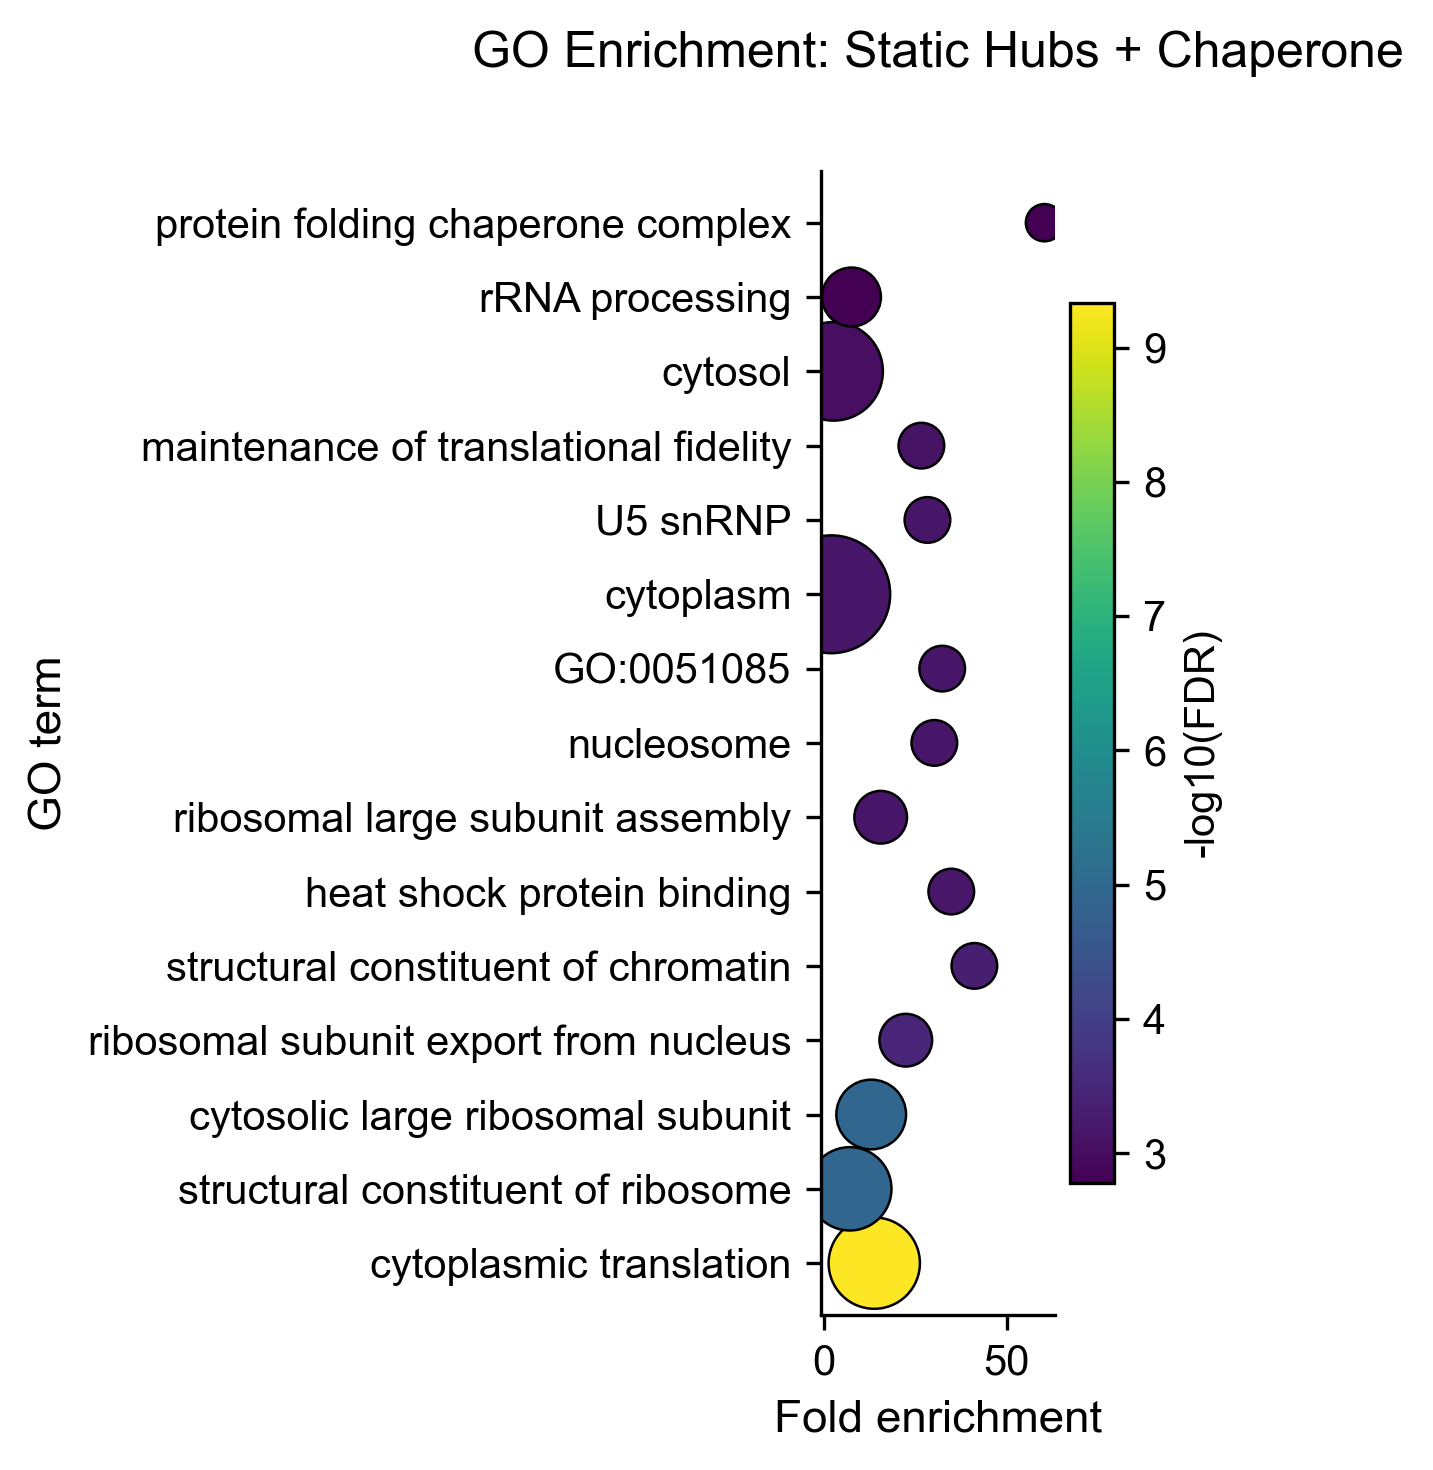

In [47]:
if len(static_go) > 0:
    plot_df = static_go.sort_values("FDR").head(15).copy()
    plot_df["neglog10FDR"] = -np.log10(plot_df["FDR"] + 1e-12)

    plot_df["label"] = plot_df.apply(
        lambda r: r["GO_name"] if pd.notna(r["GO_name"]) and r["GO_name"] != "" else r["GO_ID"],
        axis=1
    )

    fig, ax = plt.subplots(figsize=(4, 5))

    scatter = ax.scatter(
        plot_df["fold_enrichment"],
        plot_df["label"],
        s = plot_df["k_test"] * 40,
        c = plot_df["neglog10FDR"],
        cmap="viridis",
        edgecolors="black",
        linewidth=0.6,
    )

    plt.colorbar(scatter, ax=ax).set_label("-log10(FDR)", fontsize=10)

    ax.set_xlabel("Fold enrichment", fontsize=11)
    ax.set_ylabel("GO term", fontsize=11)
    ax.set_title("GO Enrichment: Static Hubs + Chaperone", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUT_PATH}GO_static_chap.svg", dpi=300)
    plt.show()


In [48]:
ribosomal_go_ids = set()

for go_id, name in go_name_map.items():
    if name is None:
        continue
    text = name.lower()
    if (
        "ribosom" in text or
        "translation" in text or
        "ribonucleoprotein" in text or
        "r rna" in text or
        "rrna" in text or
        "structural constituent of ribosome" in text
    ):
        ribosomal_go_ids.add(go_id)

print("Identified ribosome-related GO IDs:", len(ribosomal_go_ids))


Identified ribosome-related GO IDs: 199


In [49]:
def is_ribosomal(go_list):
    return any(go in ribosomal_go_ids for go in go_list)

# Mark ribosomal proteins
final_df["is_ribosomal"] = final_df["GO_list"].apply(is_ribosomal)

print("Total ribosomal proteins:", final_df["is_ribosomal"].sum())


Total ribosomal proteins: 806


In [50]:
dynamic_chap_no_ribo = final_df[
    (final_df["hub_type"] == "dynamic") &
    (final_df["num_chaperone_interactions"] > 0) &
    (~final_df["is_ribosomal"])
].copy()

print("Dynamic+Chaperone (NO ribosomal) n =", len(dynamic_chap_no_ribo))


Dynamic+Chaperone (NO ribosomal) n = 8


In [52]:
# --- 3A. Background GO counts ---
all_go_bg = []
for lst in background["GO_list"]:
    all_go_bg.extend(lst)
background_counts = pd.Series(all_go_bg).value_counts()

# --- 3B. Test GO counts (dynamic + chaperone) ---
all_go_test = []
for lst in dynamic_chap_no_ribo["GO_list"]:
    all_go_test.extend(lst)
test_counts = pd.Series(all_go_test).value_counts()

# We'll only test GO terms that appear at least 2 times in the test set
unique_go_terms = test_counts[test_counts >= 2].index

results = []
N = len(background)        # universe size
n = len(dynamic_chap)      # test set size

for go in unique_go_terms:
    K = background_counts.get(go, 0)   # count in background
    k = test_counts.get(go, 0)         # count in test set
    if K == 0:
        continue

    # hypergeometric P(X >= k)
    pval = hypergeom.sf(k - 1, N, K, n)
    fold = (k / n) / (K / N)

    # human-readable name from global map, fallback to GO ID
    readable = go_name_map.get(go, go)

    results.append([go, readable, k, K, fold, pval])

go_enrich = pd.DataFrame(
    results,
    columns=["GO_ID", "GO_name", "k_test", "K_background", "fold_enrichment", "p_value"]
)

print("Total GO terms tested:", len(go_enrich))

if len(go_enrich) == 0:
    print("No GO terms met the minimum criteria (freq >= 2 in test set).")
else:
    # FDR correction
    go_enrich["FDR"] = multipletests(go_enrich["p_value"], method="fdr_bh")[1]
    # sort by FDR and keep top 15
    go_sig = go_enrich.sort_values("FDR").head(15)
    print(go_sig)

Total GO terms tested: 8
        GO_ID                                        GO_name  k_test  \
5  GO:0017101  aminoacyl-tRNA synthetase multienzyme complex       2   
3  GO:1990825                 sequence-specific mRNA binding       3   
7  GO:0035999               tetrahydrofolate interconversion       2   
0  GO:0005737                                      cytoplasm       5   
2  GO:0005829                                        cytosol       4   
1  GO:0005524                                    ATP binding       5   
4  GO:0005634                                        nucleus       2   
6  GO:0005739                                  mitochondrion       2   

   K_background  fold_enrichment   p_value       FDR  
5             3        46.750000  0.000594  0.004751  
3            21        10.017857  0.003046  0.010685  
7             7        20.035714  0.004007  0.010685  
0          1561         0.224616  1.000000  1.000000  
2           821         0.341657  0.998816  1.00000

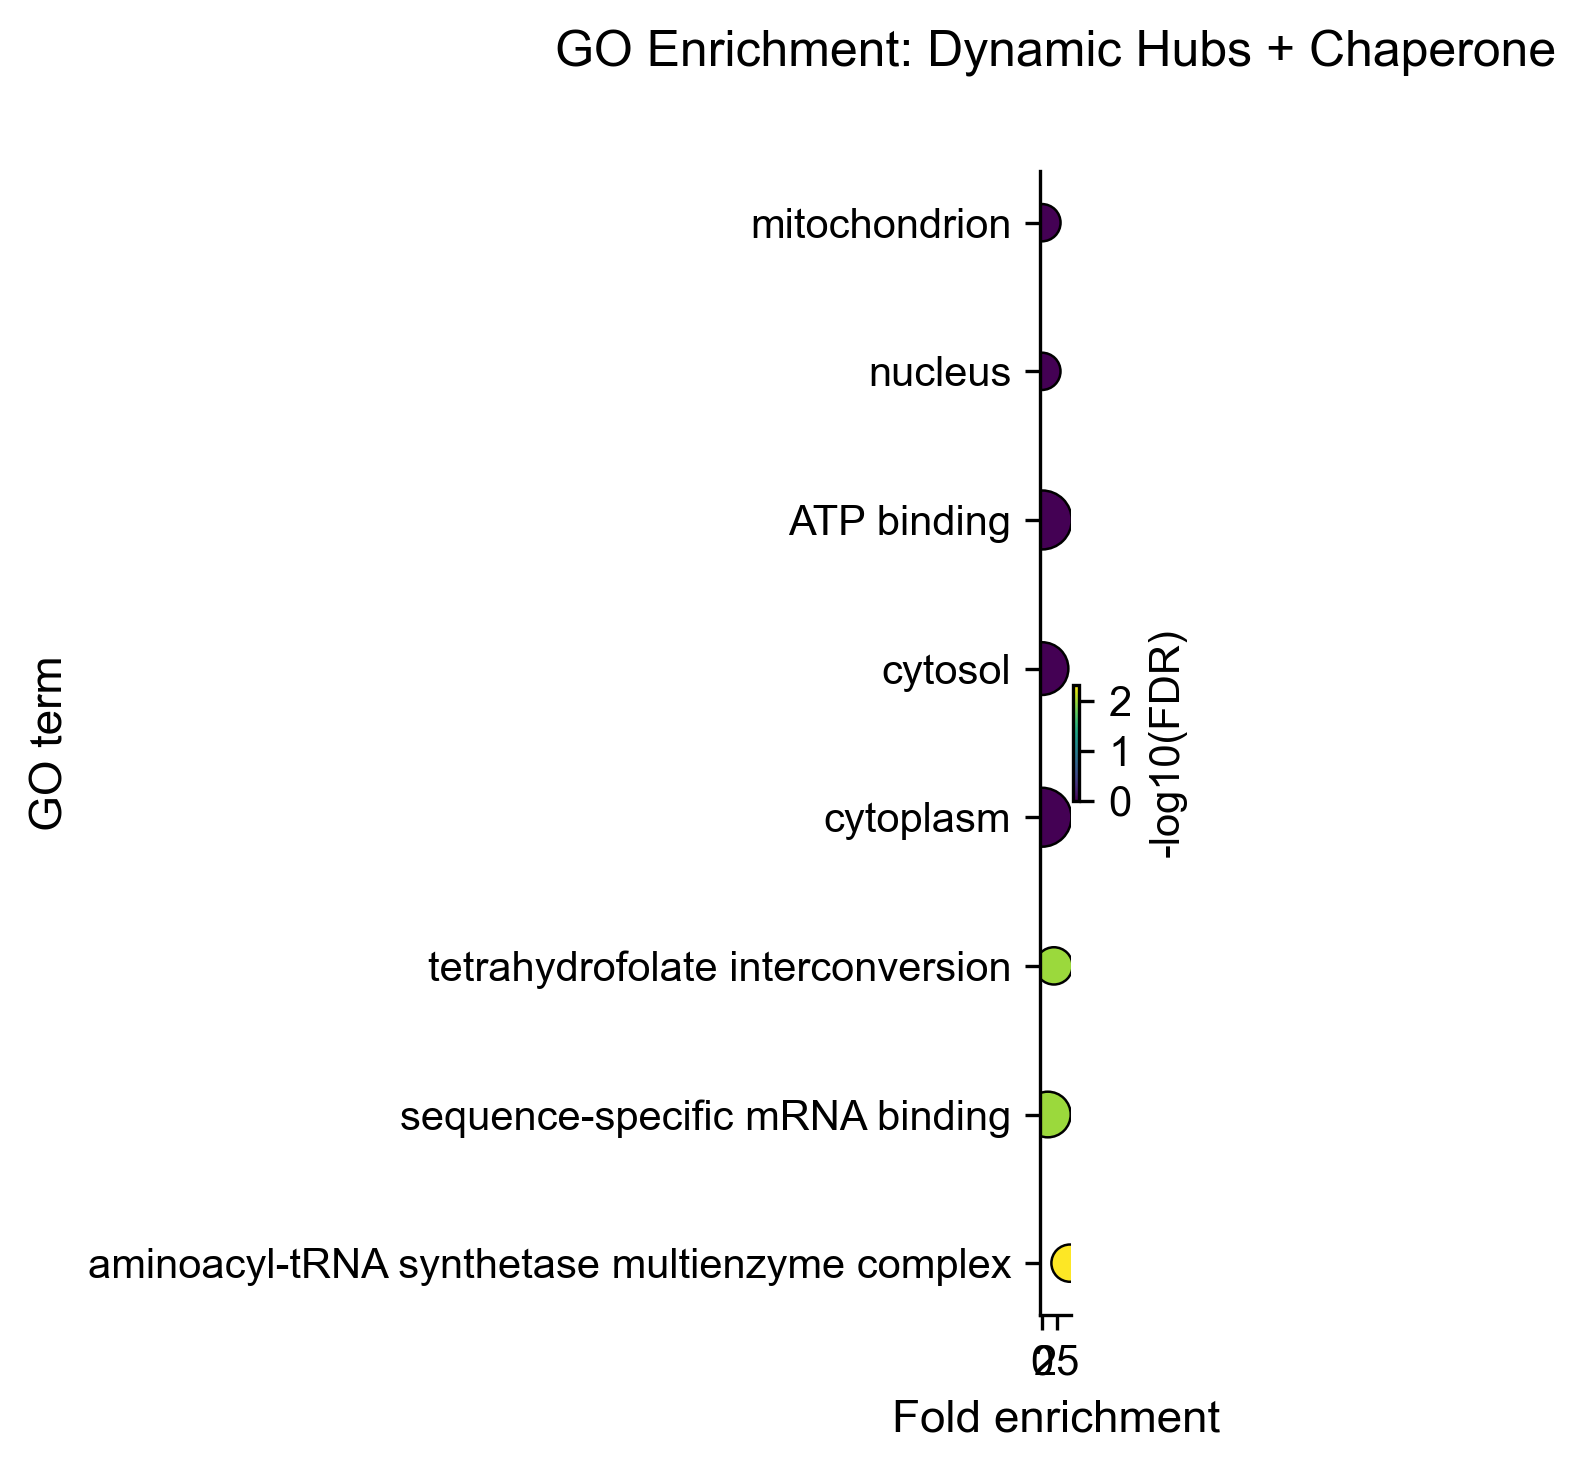

In [53]:
if len(go_enrich) > 0:

    plot_df = go_enrich.sort_values("FDR").head(15).copy()
    plot_df["neglog10FDR"] = -np.log10(plot_df["FDR"] + 1e-12)

    # Use human-readable name when available, otherwise GO ID
    plot_df["label"] = plot_df.apply(
        lambda r: r["GO_name"] if pd.notna(r["GO_name"]) and r["GO_name"] != "" else r["GO_ID"],
        axis=1
    )

    fig, ax = plt.subplots(figsize=(4, 5))

    scatter = ax.scatter(
        plot_df["fold_enrichment"],
        plot_df["label"],
        s=plot_df["k_test"] * 40,
        c=plot_df["neglog10FDR"],
        cmap="viridis",
        edgecolors="black",
        linewidth=0.6,
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("-log10(FDR)", fontsize=10)

    ax.set_xlabel("Fold enrichment", fontsize=11)
    ax.set_ylabel("GO term", fontsize=11)
    ax.set_title("GO Enrichment: Dynamic Hubs + Chaperone", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUT_PATH}GO_dynamic_chap_dotplot.svg", dpi=300)
    plt.show()